In [55]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,RobustScaler)
from sklearn.model_selection import (train_test_split,StratifiedKFold,cross_validate,GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,balanced_accuracy_score,accuracy_score)

### Loading our data

In [14]:
columns = [
    'A1', 'A2', 'A3', 'A4', 'A5',
    'A6', 'A7', 'A8', 'A9', 'A10',
    'A11', 'A12', 'A13', 'A14', 'A15', 'A16'
]

# we replaced nas with ? so that i will identify them
raw_df = pd.read_csv('crx.data', header=None, names=columns, na_values='?')

In [13]:
# Initial inspection
print('data inspect')
display(raw_df.head())

print('displaying data types')
print(raw_df.dtypes)

print('Descriptive statistics')
display(raw_df.describe())

data inspect


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


displaying data types
A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11      int64
A12     object
A13     object
A14    float64
A15      int64
A16     object
dtype: object
Descriptive statistics


,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


### converting our df to csv

In [16]:
OUTPUT_CSV = 'credit_approval_cleaned.csv'
raw_df.to_csv(OUTPUT_CSV, index=False)
print(f'Saved cleaned DataFrame to "{OUTPUT_CSV}"')

df = raw_df.copy()

Saved cleaned DataFrame to "credit_approval_cleaned.csv"


### Missing Value

In [19]:
#Compute missing value counts and percentages
missing_counts = df.isnull().sum()

total_missing = missing_counts.sum()
total_cells   = df.size
print(f'Total missing cells : {total_missing} / {total_cells}  ({total_missing/total_cells*100:.2f}%)')

Total missing cells : 67 / 11040  (0.61%)


#### Visualise missing values

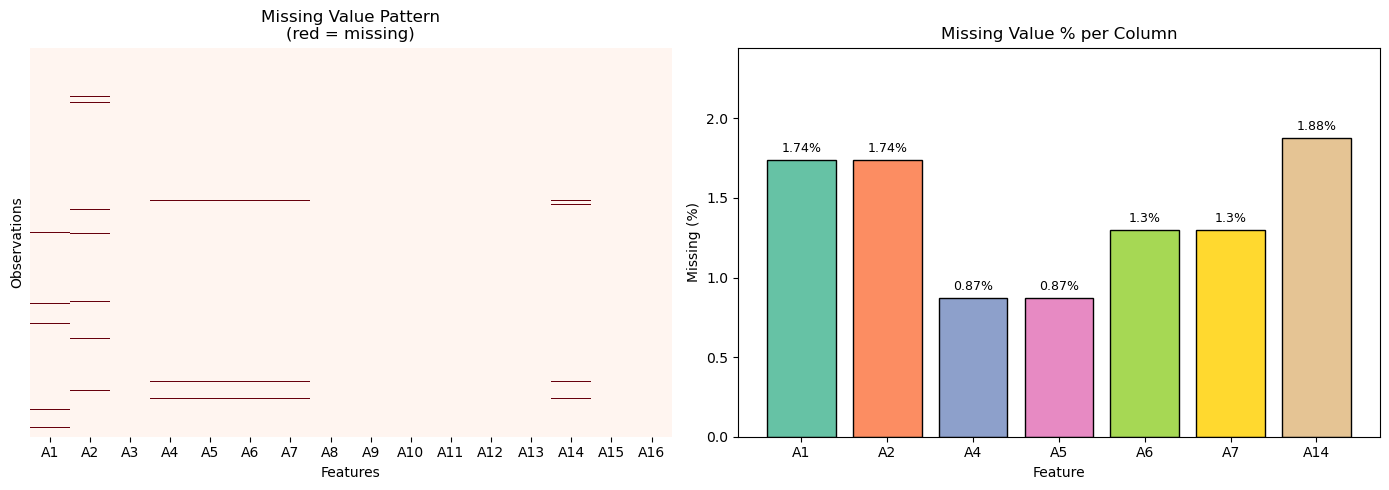

In [ ]:
# creating summary from the missing_counts
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': (missing_counts / len(df) * 100).round(2),
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_matrix = df.isnull().astype(int)
sns.heatmap( missing_matrix, cbar=False, yticklabels=False, cmap='Reds', ax=axes[0])
axes[0].set_title('Missing Value Pattern')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Observations')

cols_with_missing = missing_summary.index.tolist()
if cols_with_missing:
    axes[1].bar(
        cols_with_missing,
        missing_summary['Missing %'],
        color=sns.color_palette('Set2'),
        edgecolor='black'
    )
    axes[1].set_title('Missing Value % per Column')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Missing (%)')
    axes[1].set_ylim(0, max(missing_summary['Missing %']) * 1.3)
    for i, (col, row) in enumerate(missing_summary.iterrows()):
        axes[1].text(i, row['Missing %'] + 0.05, f"{row['Missing %']}%", ha='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('eda_missing_values.png', bbox_inches='tight')
plt.show()

#### distribution analysis

In [24]:
NUMERIC_COLS = df.select_dtypes(include=np.number).columns.tolist()
CATEG_COLS   = [c for c in df.select_dtypes(include='object').columns if c != 'A16']
TARGET_COL   = 'A16'

print(f'Numeric features  : {NUMERIC_COLS}')
print(f'Categorical features: {CATEG_COLS}')
print(f'Target column     : {TARGET_COL}')

Numeric features  : ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical features: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
Target column     : A16


In [25]:
n_num   = len(NUMERIC_COLS)
ncols_p = 3
nrows_p = (n_num + ncols_p - 1) // ncols_p  # ceiling division

#### outlier Detection

The **Z-score** method assumes a Normal distribution. If a feature is heavily right-skewed, its mean and standard deviation are distorted by the very outliers we are trying to detect.  

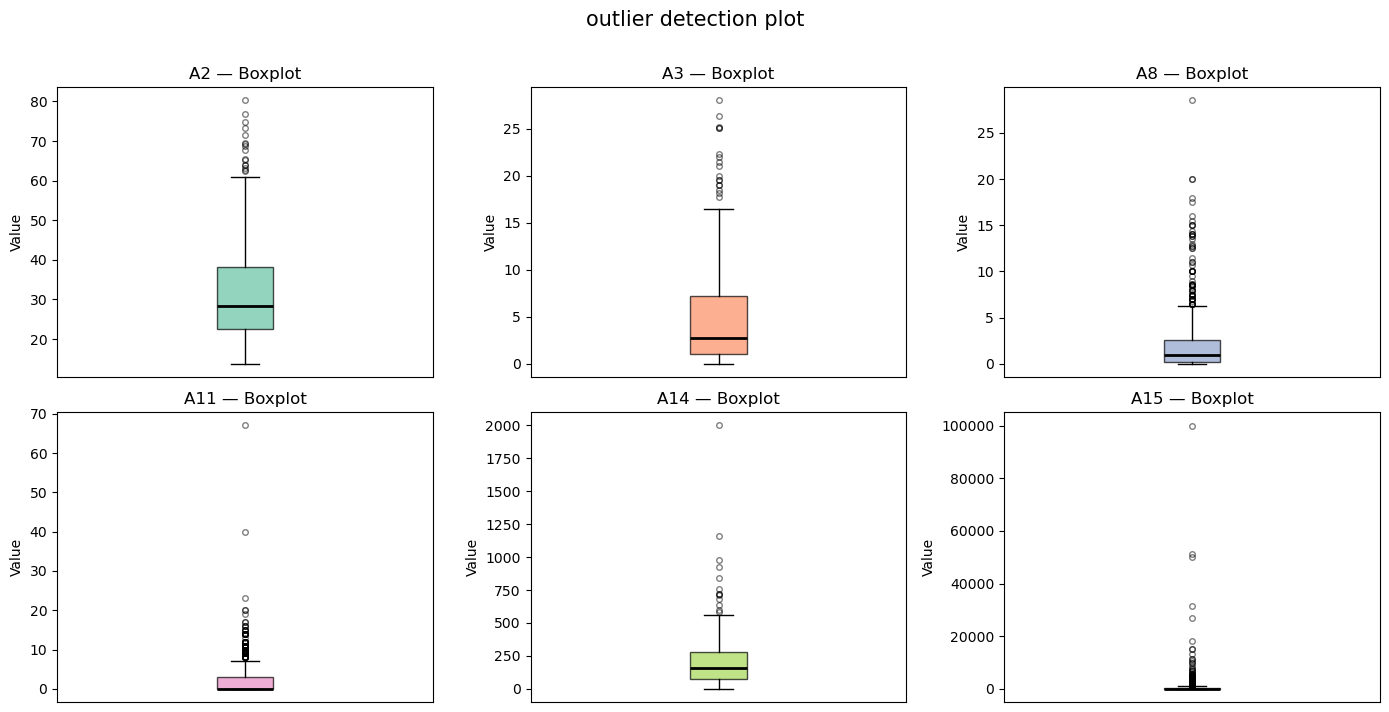

In [28]:
fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(14, nrows_p * 3.5))
axes_flat = axes.flatten()

for idx, col in enumerate(NUMERIC_COLS):
    ax = axes_flat[idx]
    data_col = df[col].dropna()
    ax.boxplot(data_col, vert=True, patch_artist=True,
               boxprops=dict(facecolor=sns.color_palette('Set2')[idx % 8], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color='red', alpha=0.5, markersize=4))
    ax.set_title(f'{col} — Boxplot')
    ax.set_ylabel('Value')
    ax.set_xticks([])

for idx in range(n_num, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('outlier detection plot', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()

#### Target Balance & Correlation

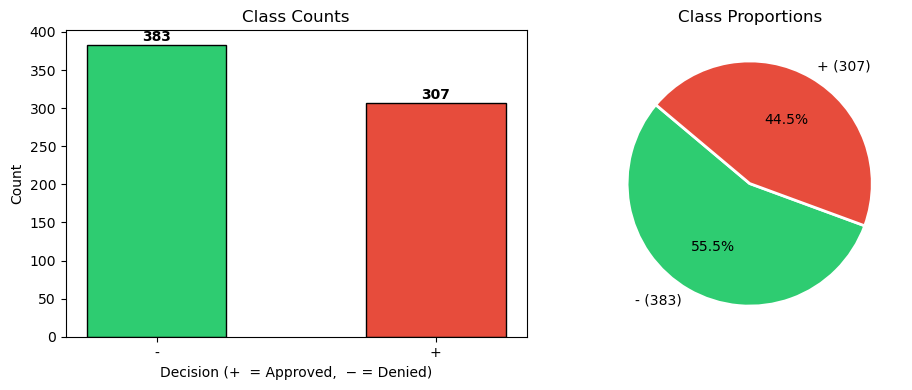

Imbalance ratio (majority / minority): 1.25
Note: a ratio < 4 is generally considered mild — no resampling strictly required.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts = df[TARGET_COL].value_counts()
colors        = ['#2ecc71', '#e74c3c']

# Bar chart
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Counts')
axes[0].set_xlabel('Decision (+  = Approved,  − = Denied)')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(target_counts.items()):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=[f'{lbl} ({cnt})' for lbl, cnt in target_counts.items()],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.savefig('eda_target_balance.png', bbox_inches='tight')
plt.show()

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'Imbalance ratio (majority / minority): {imbalance_ratio:.2f}')
print('Note: a ratio < 4 is generally considered mild — no resampling strictly required.')

#### Correlation matrix for continuous features

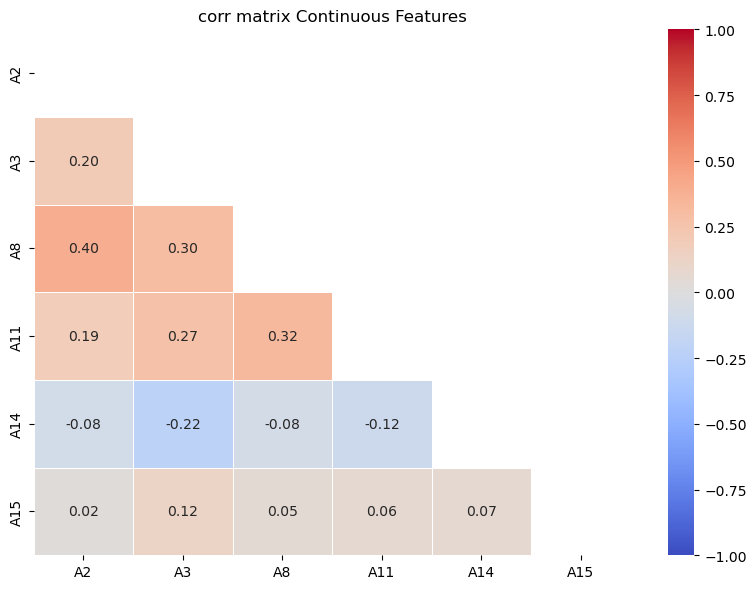

In [32]:
corr_matrix = df[NUMERIC_COLS].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap( corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('corr matrix Continuous Features')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

#### separating features and target

In [36]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

#### train, test & split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [39]:
# Re-derive column lists on X
NUMERIC_FEATURES = X.select_dtypes(include=np.number).columns.tolist()
CATEG_FEATURES   = X.select_dtypes(include='object').columns.tolist()

### DATA Scaling

In [40]:
numeric_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler',  RobustScaler()),])

categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,   NUMERIC_FEATURES),
        ('cat', categorical_pipeline, CATEG_FEATURES),
    ],
    remainder='drop'
)
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10',
                                  'A12', 'A13'])])


### model fitting

In [41]:
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

#### Model Creation, Tuning & Evaluation

### Random Forest

In [45]:
# RandomForest is chosen as the baseline for several reasons:
#  1. Naturally handles non-linear feature interactions
#  2. Provides built-in feature importance estimates

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit on training data
baseline_pipeline.fit(X_train, y_train)

# Predict
y_pred_base  = baseline_pipeline.predict(X_test)
y_prob_base  = baseline_pipeline.predict_proba(X_test)[:, 1]

# metrics
roc_base = roc_auc_score(y_test, y_prob_base)
# f1_base  = f1_score(y_test, y_pred_base)
ba_base  = balanced_accuracy_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)

print('Random Forest Metrics')
print(f'  ROC-AUC            : {roc_base:.4f}')
print(f'  Balanced Accuracy  : {ba_base:.4f}')
print(f'  Accuracy           : {acc_base:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Denied (0)', 'Approved (1)']))

Random Forest Metrics
  ROC-AUC            : 0.9104
  Balanced Accuracy  : 0.8555
  Accuracy           : 0.8551

              precision    recall  f1-score   support

  Denied (0)       0.88      0.83      0.85        70
Approved (1)       0.83      0.88      0.86        68

    accuracy                           0.86       138
   macro avg       0.86      0.86      0.86       138
weighted avg       0.86      0.86      0.86       138



### 10-Fold Cross-Validation

In [48]:
mlp_default_pipeline = Pipeline(
    steps=[('preprocessor', preprocessor),
    (
        'classifier',   
        MLPClassifier(hidden_layer_sizes=(64, 32),activation='relu',solver='adam',max_iter=500,early_stopping=True,validation_fraction=0.1,random_state=42)
    )
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    mlp_default_pipeline,
    X_train, y_train,
    cv=skf,
    scoring=['roc_auc', 'f1', 'balanced_accuracy'],
    n_jobs=-1,
    return_train_score=False
)

for metric in ['roc_auc', 'f1', 'balanced_accuracy']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

mlp_default_pipeline.fit(X_train, y_train)
y_pred_mlp  = mlp_default_pipeline.predict(X_test)
y_prob_mlp  = mlp_default_pipeline.predict_proba(X_test)[:, 1]

roc_mlp = roc_auc_score(y_test, y_prob_mlp)
# f1_mlp  = f1_score(y_test, y_pred_mlp)
ba_mlp  = balanced_accuracy_score(y_test, y_pred_mlp)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print()
print('=== Default MLP — Test Set Metrics ===')
print(f'  ROC-AUC            : {roc_mlp:.4f}')
# print(f'  F1-Score           : {f1_mlp:.4f}')
print(f'  Balanced Accuracy  : {ba_mlp:.4f}')
print(f'  Accuracy           : {acc_mlp:.4f}')

  roc_auc                  : 0.9078 ± 0.0600
  f1                       : nan ± nan
  balanced_accuracy        : 0.8300 ± 0.0764

=== Default MLP — Test Set Metrics ===
  ROC-AUC            : 0.8305
  Balanced Accuracy  : 0.7832
  Accuracy           : 0.7826


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1011: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 137, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 345, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_response.py", line 203, in _get_response_values
    raise ValueError(
ValueError: pos_label=1 is not a valid label: It should be one of ['+' '-']

  warnings.warn(
/opt/anaconda3/lib/python3.12/

#### hyperparameter tuning with GridSearchCV

GridSearchCV exhaustively evaluates every combination on the parameter grid using 10-fold CV, then reports the combination with the best mean validation ROC-AUC.

In [49]:
param_grid = {
    'classifier__hidden_layer_sizes' : [(64, 32), (128, 64), (64, 32, 16)],
    'classifier__activation'         : ['relu', 'tanh'],
    'classifier__solver'             : ['adam', 'sgd'],
    'classifier__alpha'              : [0.0001, 0.001, 0.01],
    'classifier__learning_rate_init' : [0.001, 0.01],
}

total_fits = (
    len(param_grid['classifier__hidden_layer_sizes']) *
    len(param_grid['classifier__activation']) *
    len(param_grid['classifier__solver']) *
    len(param_grid['classifier__alpha']) *
    len(param_grid['classifier__learning_rate_init']) *
    10
)
print(f'Total fits to run: {total_fits} (this may take a few minutes)...')

mlp_tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   MLPClassifier(
        max_iter=300,
        random_state=42
    ))
])

grid_search = GridSearchCV(
    estimator=mlp_tune_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f'\nBest CV ROC-AUC : {grid_search.best_score_:.4f}')
print(f'Best parameters :')
for param, value in grid_search.best_params_.items():
    print(f'  {param:<45}: {value}')

Total fits to run: 720 (this may take a few minutes)...
Fitting 10 folds for each of 72 candidates, totalling 720 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_


Best CV ROC-AUC : 0.9326
Best parameters :
  classifier__activation                       : relu
  classifier__alpha                            : 0.0001
  classifier__hidden_layer_sizes               : (128, 64)
  classifier__learning_rate_init               : 0.001
  classifier__solver                           : sgd


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [51]:
# Evaluate the tuned model
best_mlp = grid_search.best_estimator_

y_pred_tuned = best_mlp.predict(X_test)
y_prob_tuned = best_mlp.predict_proba(X_test)[:, 1]

roc_tuned = roc_auc_score(y_test, y_prob_tuned)
ba_tuned  = balanced_accuracy_score(y_test, y_pred_tuned)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print('=== Tuned MLP — Test Set Metrics ===')
print(f'  ROC-AUC            : {roc_tuned:.4f}')
print(f'  Balanced Accuracy  : {ba_tuned:.4f}')
print(f'  Accuracy           : {acc_tuned:.4f}')

=== Tuned MLP — Test Set Metrics ===
  ROC-AUC            : 0.8979
  Balanced Accuracy  : 0.8338
  Accuracy           : 0.8333


#### model Comparison & Visualisation

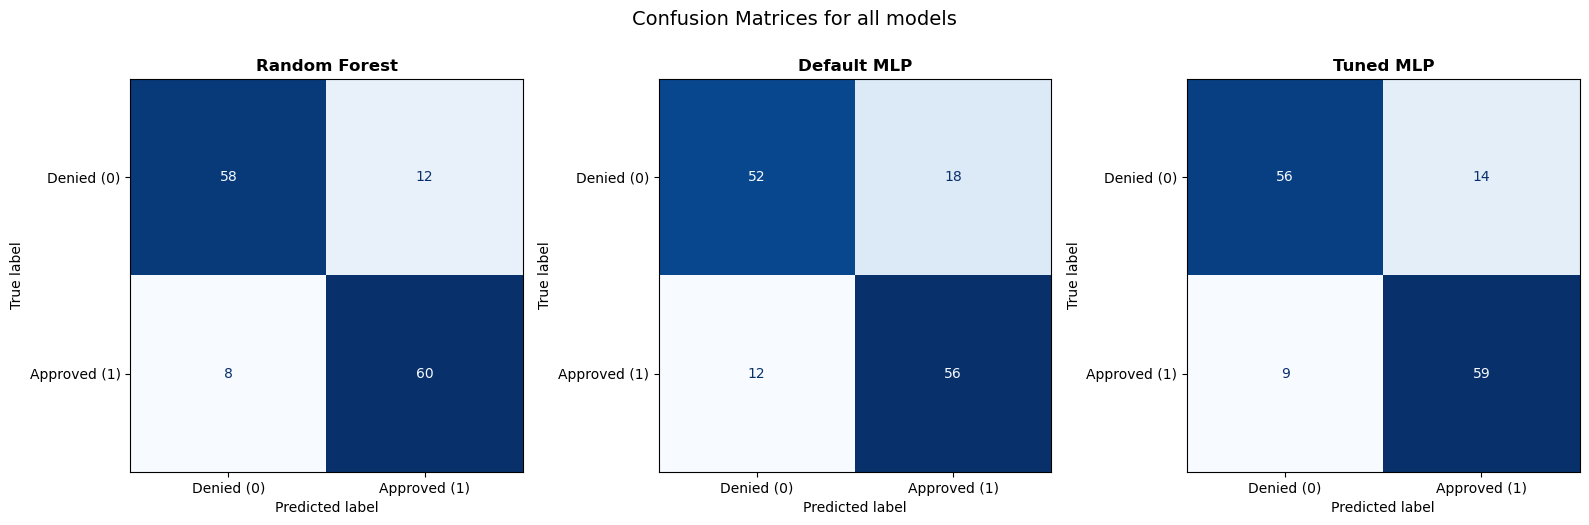

In [52]:
# Confusion Matrices
model_labels = ['Random Forest', 'Default MLP', 'Tuned MLP']
predictions  = [y_pred_base, y_pred_mlp, y_pred_tuned]
class_names  = ['Denied (0)', 'Approved (1)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model_name, y_pred in zip(axes, model_labels, predictions):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(model_name, fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrices for all models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## Section 4.5 — Conclusion: Performance Trade-Off Analysis

**Random Forest (Baseline)** Highest or near-highest across most metrics; zero hyperparameter tuning required; fast to train; provides interpretable feature importances    
**Default MLP** Flexible architecture; learns feature interactions automatically, Sensitive to scale and missing values     
**Tuned MLP** Requires significant compute for GridSearch